# 🧪 Chapter 3: Statistical Experiments and Significance Testing
**Referensi Buku:** *Practical Statistics for Data Scientists* (Peter Bruce, Andrew Bruce, Peter Gedeck)

---
> **Topik:** A/B Testing, Hipotesis Nol, Uji Permutasi, P-Values, ANOVA, dan Uji Chi-Square
---
## 1. A/B Testing dan Pengujian Hipotesis
Desain eksperimen adalah pilar penting dalam menganalisis data. Salah satu bentuk eksperimen yang paling populer adalah **A/B Testing**, yaitu membandingkan dua perlakuan (misalnya Desain Web A vs Desain Web B) untuk melihat mana yang lebih baik.

Untuk memastikan bahwa perbedaan yang kita lihat bukan sekadar kebetulan acak, kita menyusun:
- **Null Hypothesis ($H_0$):** Asumsi dasar bahwa tidak ada perbedaan nyata antara grup A dan grup B. Perbedaan yang terlihat hanya karena variasi acak acak (*chance*).
- **Alternative Hypothesis ($H_1$):** Hipotesis yang ingin kita buktikan, yaitu bahwa memang ada perbedaan nyata antara grup A dan B.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import random

%matplotlib inline
np.random.seed(42)

# Simulasi data A/B Testing (Misal: Waktu yang dihabiskan pengunjung di halaman web dalam detik)
time_page_A = np.random.normal(loc=120, scale=30, size=50) # Halaman A (Control)
time_page_B = np.random.normal(loc=135, scale=30, size=50) # Halaman B (Treatment)

obs_diff = np.mean(time_page_B) - np.mean(time_page_A)
print(f"Rata-rata Waktu Halaman A: {np.mean(time_page_A):.2f} detik")
print(f"Rata-rata Waktu Halaman B: {np.mean(time_page_B):.2f} detik")
print(f"Perbedaan Observasi (Observed Difference): {obs_diff:.2f} detik")

Rata-rata Waktu Halaman A: 113.24 detik
Rata-rata Waktu Halaman B: 135.53 detik
Perbedaan Observasi (Observed Difference): 22.30 detik


Dari observasi di atas, Halaman B menahan pengunjung lebih lama. Pertanyaannya: **Apakah perbedaan ini signifikan secara statistik, atau hanya kebetulan?**

## 2. Resampling: Uji Permutasi (Permutation Test)
Buku ini sangat menekankan pendekatan *resampling* karena lebih intuitif daripada mengandalkan rumus rumus t-test klasik yang membutuhkan asumsi distribusi normal.

**Logika Uji Permutasi:**
Jika Hipotesis Nol ($H_0$) benar (tidak ada perbedaan antara A dan B), maka label "A" dan "B" tidak ada maknanya. Jadi, kita bisa mencampur seluruh data, lalu membaginya kembali menjadi grup A dan B secara acak berkali-kali. Jika selisih dari pengacakan ini jarang mencapai selisih observasi asli kita, berarti perbedaan aslinya valid (bukan kebetulan).

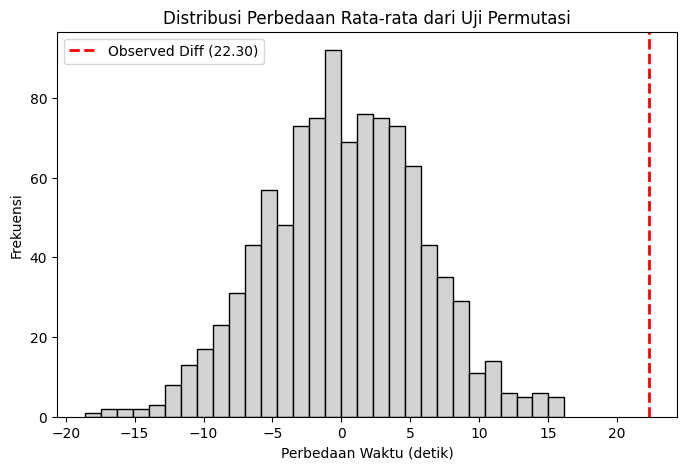

In [2]:
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

# Gabungkan semua data
all_times = pd.Series(np.concatenate([time_page_A, time_page_B]))
nA = len(time_page_A)
nB = len(time_page_B)

# Lakukan permutasi sebanyak 1000 kali
perm_diffs = [perm_fun(all_times, nA, nB) for _ in range(1000)]

# Visualisasi hasil permutasi
plt.figure(figsize=(8, 5))
plt.hist(perm_diffs, bins=30, color='lightgray', edgecolor='black')
plt.axvline(x=obs_diff, color='red', linestyle='dashed', linewidth=2, label=f'Observed Diff ({obs_diff:.2f})')
plt.title('Distribusi Perbedaan Rata-rata dari Uji Permutasi')
plt.xlabel('Perbedaan Waktu (detik)')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

## 3. P-Value dan Signifikansi Statistik
Grafik di atas menunjukkan distribusi jika $H_0$ benar. Garis merah adalah hasil aktual eksperimen kita.
- **P-Value (Nilai-p):** Peluang mendapatkan hasil seekstrem (atau lebih ekstrem dari) hasil observasi kita, **jika hipotesis nol benar**.
- **Alpha (Tingkat Signifikansi):** Ambang batas (biasanya 0.05 atau 5%). Jika P-Value < Alpha, kita tolak $H_0$ (hasilnya signifikan).

Mari kita hitung p-value dari permutasi kita, dan bandingkan dengan *t-Test* klasik menggunakan modul SciPy.

In [3]:
# Menghitung P-Value dari Permutasi
p_value_perm = np.mean([diff >= obs_diff for diff in perm_diffs])
print(f"P-Value (Permutation Test) : {p_value_perm:.4f}")

# Membandingkan dengan t-Test klasik
t_stat, p_value_ttest = stats.ttest_ind(time_page_B, time_page_A, alternative='greater')
print(f"P-Value (Classic t-Test)   : {p_value_ttest:.4f}")

if p_value_perm < 0.05:
    print("\nKesimpulan: P-Value < 0.05. Kita menolak H0. Perbedaan ini SIGNIFIKAN secara statistik.")
else:
    print("\nKesimpulan: P-Value >= 0.05. Gagal menolak H0. Perbedaan TIDAK signifikan.")

P-Value (Permutation Test) : 0.0000
P-Value (Classic t-Test)   : 0.0000

Kesimpulan: P-Value < 0.05. Kita menolak H0. Perbedaan ini SIGNIFIKAN secara statistik.


## 4. ANOVA (Analysis of Variance)
Jika A/B Test digunakan untuk membandingkan 2 grup, **ANOVA** digunakan ketika kita membandingkan **lebih dari 2 grup** (misal: Halaman A, B, C, dan D). ANOVA menguji apakah ada *setidaknya satu* grup yang memiliki rata-rata yang berbeda secara signifikan.

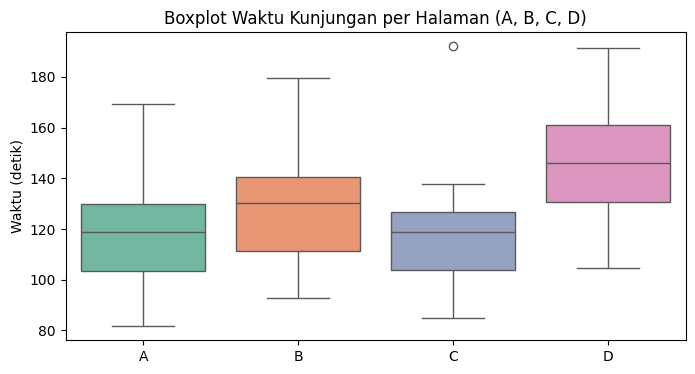

F-Statistic ANOVA : 16.52
P-Value ANOVA     : 0.000000


In [4]:
# Simulasi data 4 halaman berbeda
page_A = np.random.normal(loc=120, scale=20, size=40)
page_B = np.random.normal(loc=125, scale=20, size=40)
page_C = np.random.normal(loc=115, scale=20, size=40)
page_D = np.random.normal(loc=145, scale=20, size=40) # Grup D memiliki lonjakan waktu yang besar

df_anova = pd.DataFrame({'A': page_A, 'B': page_B, 'C': page_C, 'D': page_D})

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_anova, palette="Set2")
plt.title('Boxplot Waktu Kunjungan per Halaman (A, B, C, D)')
plt.ylabel('Waktu (detik)')
plt.show()

# Uji F-Statistic (ANOVA) dengan SciPy
f_stat, p_value_anova = stats.f_oneway(page_A, page_B, page_C, page_D)
print(f"F-Statistic ANOVA : {f_stat:.2f}")
print(f"P-Value ANOVA     : {p_value_anova:.6f}")

## 5. Chi-Square Test (Uji Chi-Kuadrat)
Digunakan untuk **data frekuensi atau hitungan (count data)**, bukan data metrik kontinu. Uji ini menanyakan: "Apakah distribusi kejadian (observed) menyimpang secara signifikan dari distribusi yang kita harapkan (expected)?"

Contoh: Mengecek apakah rasio klik (Click-Through Rate) dari 3 headline berita berbeda signifikan secara statistik.

In [5]:
# Data Observasi: [Klik, Tidak Klik] untuk 3 Headline
clicks = np.array([
    [14, 986],  # Headline A
    [8, 992],   # Headline B
    [20, 980]   # Headline C
])

chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(clicks)

print("Tabel Frekuensi (Observed):")
print(pd.DataFrame(clicks, columns=['Klik', 'Tidak Klik'], index=['A', 'B', 'C']))
print(f"\nChi-Square Statistic : {chi2_stat:.3f}")
print(f"P-Value              : {p_val_chi2:.4f}")

if p_val_chi2 < 0.05:
    print("\nKesimpulan: Ada perbedaan CTR yang signifikan antar headline.")
else:
    print("\nKesimpulan: Perbedaan CTR tidak signifikan, mungkin hanya variasi acak.")

Tabel Frekuensi (Observed):
   Klik  Tidak Klik
A    14         986
B     8         992
C    20         980

Chi-Square Statistic : 5.216
P-Value              : 0.0737

Kesimpulan: Perbedaan CTR tidak signifikan, mungkin hanya variasi acak.
